In [ ]:
import numpy as np
import discretize
import matplotlib.pyplot as plt

import sys, os
sys.path.append(os.path.abspath("../../../../"))

from Forward.MT3D import compute_mt_impedance_tipper
from Forward.utils import apparent_resistivity
from Forward.utils import phase_deg

In [ ]:
# 1) Modelo (Δσ)
# El NPY trae contraste de conductividad Δσ en S/m 

# Frecuencias en las que se va a hacer el modelado
frequency_list = np.logspace(-4, 2, 7)

# Ubicación del receptor para el modelado
receivers = np.array([
    [0.0, 0.0, 0.0],
])

# Carga de la malla usada para el modelo 2D de conductividad ##############
mesh = discretize.utils.load_mesh("../../../../models/Toy4/mesh_Toy4_MT.json")

# Carga del modelo 2D de conductividad
sigma = np.load("../../../../models/Toy4/model_Toy4_MT.npy", allow_pickle=True)

print("mesh =", mesh)
print("mesh.nC=", mesh.nC)
print("mesh.nEx=", mesh.nEx)
print("mesh.nEy=", mesh.nEy)
print("mesh.nEz=", mesh.nEz)
print("frequency_list =", frequency_list)
print("receivers =", receivers)

mesh = 
  TensorMesh: 4,312 cells

                      MESH EXTENT             CELL WIDTH      FACTOR
  dir    nC        min           max         min       max      max
  ---   ---  ---------------------------  ------------------  ------
   x     14     -3,439.01      3,439.01    250.00    928.23    1.30
   y     14     -3,439.01      3,439.01    250.00    928.23    1.30
   z     22     -3,087.43      3,387.43    150.00    724.02    1.30


mesh.nC= 4312
mesh.nEx= 4830
mesh.nEy= 4830
mesh.nEz= 4950
frequency_list = [1.e-04 1.e-03 1.e-02 1.e-01 1.e+00 1.e+01 1.e+02]
receivers = [[0. 0. 0.]]


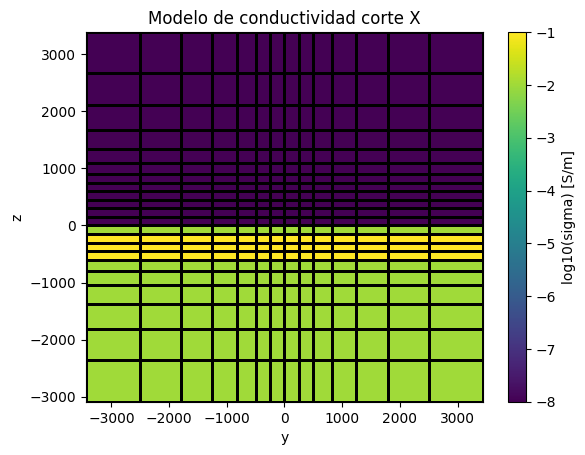

In [ ]:
# 2) Plot del modelo de conductividad
collect_obj = mesh.plot_slice(np.log10(sigma), grid=True, normal="X")[0]
plt.colorbar(collect_obj, label="log10(sigma) [S/m]")
plt.title("Modelo de conductividad corte X")
plt.show()

In [29]:
# 3) Forward

Z, T = compute_mt_impedance_tipper(mesh, sigma, receivers, frequency_list)

# Se guardan el tensor de impedancias y el tipper
np.save("impedance_Toy4.npy", Z)
np.save("tipper_Toy4.npy", T)

# Se imprimen los resultados obtenidos
print("Computed shapes -> Z:", Z.shape, "T:", T.shape)

for i, r in enumerate(receivers):
    for j, f in enumerate(frequency_list):
        print(
            f"Rec {i} {r}, f={f} Hz -> "
            f"Zxy={Z[i,j,0,1]:.4e}, Zyx={Z[i,j,1,0]:.4e}, "
            f"Tzx={T[i,j,0]:.4e}, Tzy={T[i,j,1]:.4e}"
        )

Resolviendo para la frecuencia 0 de 7
calculando la impedancia en el receptor   0/1 at [0. 0. 0.], por favor espere :)
Resolviendo para la frecuencia 1 de 7
calculando la impedancia en el receptor   0/1 at [0. 0. 0.], por favor espere :)
Resolviendo para la frecuencia 2 de 7
calculando la impedancia en el receptor   0/1 at [0. 0. 0.], por favor espere :)
Resolviendo para la frecuencia 3 de 7
calculando la impedancia en el receptor   0/1 at [0. 0. 0.], por favor espere :)
Resolviendo para la frecuencia 4 de 7
calculando la impedancia en el receptor   0/1 at [0. 0. 0.], por favor espere :)
Resolviendo para la frecuencia 5 de 7
calculando la impedancia en el receptor   0/1 at [0. 0. 0.], por favor espere :)
Resolviendo para la frecuencia 6 de 7
calculando la impedancia en el receptor   0/1 at [0. 0. 0.], por favor espere :)
Computed shapes -> Z: (1, 7, 2, 2) T: (1, 7, 2)
Rec 0 [0. 0. 0.], f=0.0001 Hz -> Zxy=-4.9301e-05-4.9501e-05j, Zyx=1.5122e-04+1.5089e-04j, Tzx=1.0909e-13-1.0889e-13j, T

In [30]:
# Se calculan los valores de resistividad y fase aparente para
# Tensor de impedancias
Zxx = Z[:, :, 0, 0]
Zxy = Z[:, :, 0, 1]
Zyx = Z[:, :, 1, 0]
Zyy = Z[:, :, 1, 1]

rhoxx = apparent_resistivity(Zxx, frequency_list)
rhoxy = apparent_resistivity(Zxy, frequency_list)
rhoyx = apparent_resistivity(Zyx, frequency_list)
rhoyy = apparent_resistivity(Zyy, frequency_list)

phixx = phase_deg(Zxx)
phixy = phase_deg(Zxy)
phiyx = phase_deg(Zyx)
phiyy = phase_deg(Zyy)

# Tipper
Tzx=T[:,:,0]
Tzy=T[:,:,1]

Tmzx = np.abs(Tzx)
Tmzy = np.abs(Tzy)

Tpzx = phase_deg(Tzx)
Tpzy = phase_deg(Tzy)

## Se imprimen los valores numéricos
print("Zxy:", Z[:, :, 0, 1])
print("Zyx:", Z[:, :, 1, 0])
print("Zxx:", Z[:, :, 0, 0])
print("Zyy:", Z[:, :, 1, 1])
print("Tzx:", T[:, :, 0])
print("Tzy:", T[:, :, 1])
print("|Tzx|:", Tmzx[:])
print("|Tzy|:", Tmzy[:])
print("Tzx°:", Tpzx[:])
print("Tzy°:", Tpzy[:])

Zxy: [[-4.93008168e-05-4.95009270e-05j -1.55907655e-04-1.57901489e-04j
  -4.93174598e-04-5.12883022e-04j -1.56433142e-03-1.75413629e-03j
  -5.09279373e-03-6.76089164e-03j -1.89951577e-02-2.99104665e-02j
  -8.33136930e-02-1.36050840e-01j]]
Zyx: [[0.00015122+0.00015089j 0.0004782 +0.00047489j 0.00151227+0.00147905j
  0.00478218+0.00444815j 0.01491315+0.01174946j 0.03377069+0.02444087j
  0.08620869+0.13524799j]]
Zxx: [[-1.70792441e+05-2.74389040e+08j -1.19792903e+07+1.41515123e+09j
  -4.76549919e+08+3.01821595e+10j  9.48643039e+09-1.65763082e+11j
  -5.32804097e+10+1.67394922e+12j -4.37825046e+12+4.57963766e+13j
  -7.14053775e+14+4.08031146e+14j]]
Zyy: [[-1.58061132e+07-2.15797719e+09j -3.52380246e+06+5.95204492e+09j
   5.05968730e+10-7.37191980e+11j -2.24536685e+10+3.75905991e+11j
   1.67328219e+12-9.98336646e+12j  7.87807109e+12+8.73934206e+13j
  -1.08196155e+15-4.76665627e+14j]]
Tzx: [[ 1.09092919e-13-1.08886676e-13j -3.43469073e-14+3.43873278e-14j
   5.36262849e-15-5.40752690e-15j  1.2

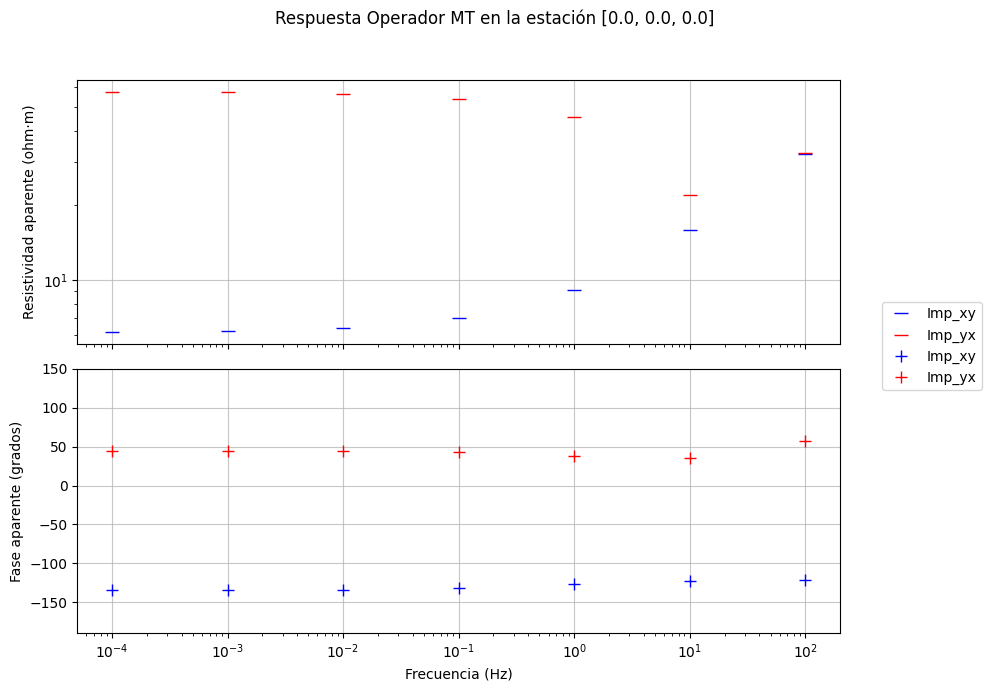

In [31]:
# 4) Plot de resistividad y fase aparente

# Se grafican los valores de resistividad y fase aparente

frec = frequency_list

# Receptor a graficar
irec = 0

# Colores por componente
c_xx = "green"
c_xy = "blue"
c_yx = "red"
c_yy = "gold"

fig, (ax_rho, ax_phi) = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

# Resistividad
ax_rho.plot(frec, rhoxy[irec, :], marker="_", linestyle="none", color=c_xy, markersize=10, label="Imp_xy")
ax_rho.plot(frec, rhoyx[irec, :], marker="_", linestyle="none", color=c_yx, markersize=10, label="Imp_yx")

ax_rho.set_xscale("log")
ax_rho.set_yscale("log")
ax_rho.set_ylabel("Resistividad aparente (ohm·m)")
ax_rho.grid(True, which="major", alpha=0.7)

# Fase
ax_phi.plot(frec, phixy[irec, :], marker="+", linestyle="none", color=c_xy, markersize=8, label="Imp_xy")
ax_phi.plot(frec, phiyx[irec, :], marker="+", linestyle="none", color=c_yx, markersize=8, label="Imp_yx")

ax_phi.set_xscale("log")
ax_phi.set_xlabel("Frecuencia (Hz)")
ax_phi.set_ylabel("Fase aparente (grados)")
ax_phi.grid(True, which="major", alpha=0.7)
ax_phi.set_ylim(-190, 150)

handles_rho, labels_rho = ax_rho.get_legend_handles_labels()
handles_phi, labels_phi = ax_phi.get_legend_handles_labels()

fig.legend(
    handles_rho + handles_phi,
    labels_rho + labels_phi,
    loc="center left",
    bbox_to_anchor=(0.88, 0.5)
)

fig.suptitle(f"Respuesta Operador MT en la estación {receivers[irec].tolist()}")

plt.tight_layout(rect=[0, 0, 0.86, 0.95])
plt.show()

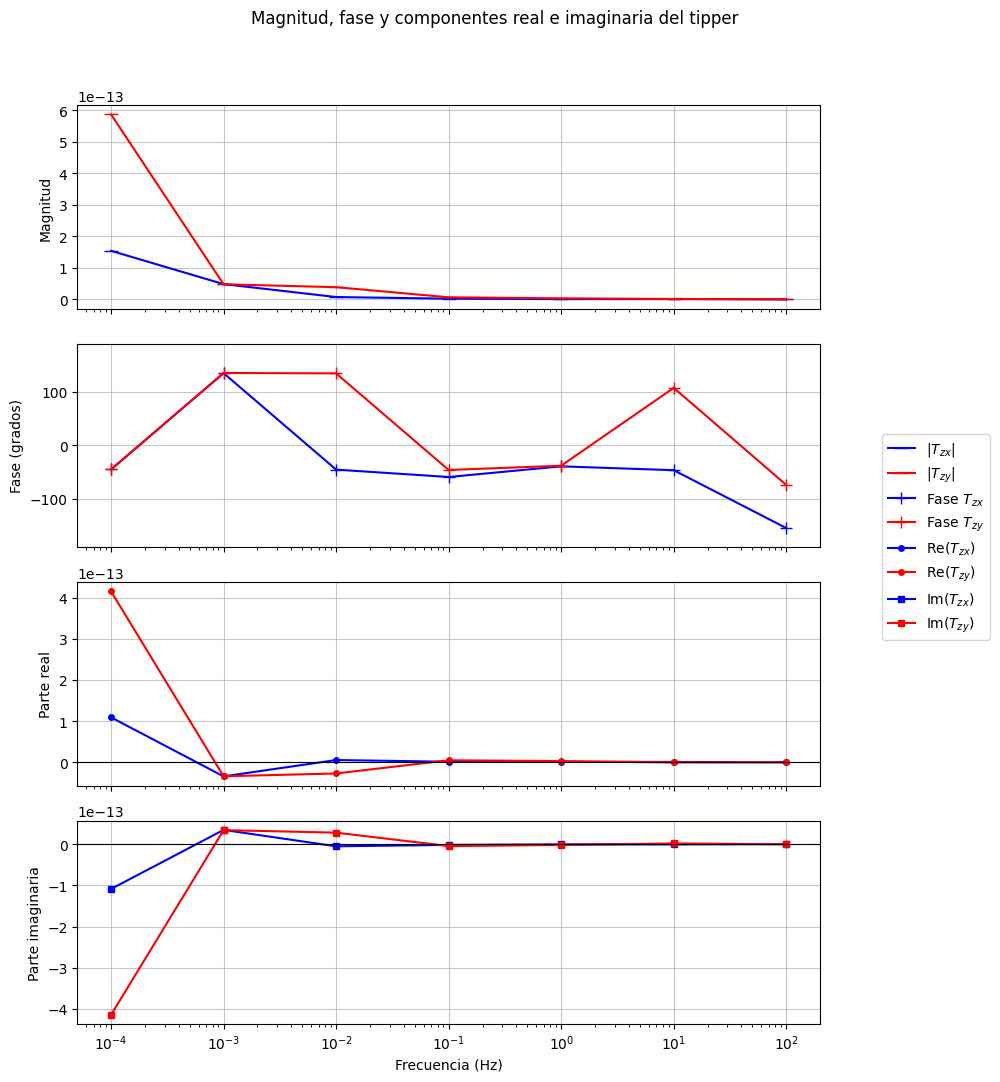

In [32]:
# Magnitud, fase, parte real e imaginaria del tipper
Tmzx = np.abs(Tzx)
Tmzy = np.abs(Tzy)

Tpzx = phase_deg(Tzx)
Tpzy = phase_deg(Tzy)

Tzx_real = np.real(Tzx)
Tzx_imag = np.imag(Tzx)

Tzy_real = np.real(Tzy)
Tzy_imag = np.imag(Tzy)

frec = frequency_list
irec = 0

# Colores por componente
c_tzx = "blue"
c_tzy = "red"

fig, (ax_mag, ax_phi, ax_real, ax_imag) = plt.subplots(
    4, 1,
    figsize=(10, 11),
    sharex=True
)

# Magnitud del tipper
ax_mag.plot(
    frec, Tmzx[irec, :],
    marker="_", linestyle="-",
    color=c_tzx, markersize=10,
    label=r"$|T_{zx}|$"
)

ax_mag.plot(
    frec, Tmzy[irec, :],
    marker="_", linestyle="-",
    color=c_tzy, markersize=10,
    label=r"$|T_{zy}|$"
)

ax_mag.set_xscale("log")
ax_mag.set_ylabel("Magnitud")
ax_mag.grid(True, which="major", alpha=0.7)

# Fase del tipper
ax_phi.plot(
    frec, Tpzx[irec, :],
    marker="+", linestyle="-",
    color=c_tzx, markersize=8,
    label=r"Fase $T_{zx}$"
)

ax_phi.plot(
    frec, Tpzy[irec, :],
    marker="+", linestyle="-",
    color=c_tzy, markersize=8,
    label=r"Fase $T_{zy}$"
)

ax_phi.set_xscale("log")
ax_phi.set_ylabel("Fase (grados)")
ax_phi.grid(True, which="major", alpha=0.7)
ax_phi.set_ylim(-190, 190)

# Parte real
ax_real.plot(
    frec, Tzx_real[irec, :],
    marker="o", linestyle="-",
    color=c_tzx, markersize=4,
    label=r"Re($T_{zx}$)"
)

ax_real.plot(
    frec, Tzy_real[irec, :],
    marker="o", linestyle="-",
    color=c_tzy, markersize=4,
    label=r"Re($T_{zy}$)"
)

ax_real.set_xscale("log")
ax_real.set_ylabel("Parte real")
ax_real.grid(True, which="major", alpha=0.7)
ax_real.axhline(0, color="black", linewidth=0.8)

# Parte imaginaria
ax_imag.plot(
    frec, Tzx_imag[irec, :],
    marker="s", linestyle="-",
    color=c_tzx, markersize=4,
    label=r"Im($T_{zx}$)"
)

ax_imag.plot(
    frec, Tzy_imag[irec, :],
    marker="s", linestyle="-",
    color=c_tzy, markersize=4,
    label=r"Im($T_{zy}$)"
)

ax_imag.set_xscale("log")
ax_imag.set_xlabel("Frecuencia (Hz)")
ax_imag.set_ylabel("Parte imaginaria")
ax_imag.grid(True, which="major", alpha=0.7)
ax_imag.axhline(0, color="black", linewidth=0.8)


handles, labels = [], []

for ax in [ax_mag, ax_phi, ax_real, ax_imag]:
    h, l = ax.get_legend_handles_labels()
    handles.extend(h)
    labels.extend(l)

fig.legend(
    handles,
    labels,
    loc="center left",
    bbox_to_anchor=(0.88, 0.5)
)

fig.suptitle("Magnitud, fase y componentes real e imaginaria del tipper")

plt.tight_layout(rect=[0, 0, 0.84, 0.95])
plt.show()